In [ ]:
!pip install pandas
!pip install seaborn

In [ ]:
import matplotlib
print(matplotlib.__version__)


3.5.1


In [ ]:
!pip3 install -Iv matplotlib==3.5.1


Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
  Using cached matplotlib-3.5.1-cp312-cp312-linux_x86_64.whl
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/b7/37/82dbef0f6342eb01f54bca073ac1498433d6ce71e50c3c3282b655733b31/fonttools-4.61.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata
  Using cached fonttools-4.61.1-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (114 kB)
  Obtaining dependency information for kiwisolver>=1.0.1 from https://files.pythonhosted.org/packages/70/90/6d240beb0f24b74371762873e9b7f499f1e02166a2

#Pandas

In [ ]:
import pandas as pd
movies = pd.read_csv("movies_data.csv")

movies["Название колонки"] # Считать значения в одной колонке
movies[['Год производства', 'Страна производства']] # Считать некоторое количество столбцов
movies.iloc[2] # Считать строку  в таблице(в данном случае мы считаем третью) не учитвая строку с названиями колонок

Фильтры

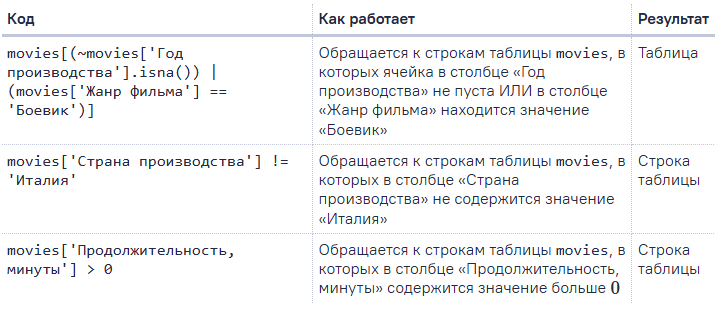

In [ ]:
len(movies[(~movies['Год производства'].isna()) & (movies["Год производства"] > 2010)])

3753

# Модификация таблиц csv


In [ ]:
movies['Продолжительность фильма, часы'] = movies['Продолжительность фильма, часы'].replace('Нет данных', '0')


In [ ]:
movies['Продолжительность фильма, часы'] = movies['Продолжительность фильма, часы'].astype('int')

1. .astype("int") приводит все значения в колонке к одному типу
2. .replace('Нет данных', '0') меняет значение в определённой колонке

In [ ]:
movies['Продолжительность фильма, часы'] * 60

In [ ]:
movies['Продолжительность фильма, часы'] * 60 + movies['Продолжительность фильма, минуты']

KeyError: 'Продолжительность фильма, часы'

Например, чтобы вычислить среднее арифметическое значений в колонке, можно воспользоваться функцией mean:

movies['Год производства'].mean()

Аналогичным образом работает функция sum, вычисляющая сумму значений, а также функции max и min для вычисления в колонке максимального и минимального значений соответственно.

Для вычисления количества строчек в колонке используется функция len:

len(movies)

В pandas есть специальная функция fillna, которая позволяет заменить все пропущенные значения в какой-то колонке на заданное. Например, исполнение кода

movies['Год производства'].fillna(2010)В pandas есть специальная функция fillna, которая позволяет заменить все пропущенные значения в какой-то колонке на заданное. Например, исполнение кода

movies['Год производства'].fillna(2010)

In [ ]:
float("nan")

nan

# Tasks

In [ ]:
import pandas as pd
movies = pd.read_csv("/content/movies_budget (1).csv", sep=";")


In [ ]:
(movies['Страна производства'] == "Франция") & (movies['Жанр фильма'] == "Драма")

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [ ]:
len(movies[(~movies['Год производства'].isna()) & (movies["Год производства"] > 2010) & (movies['Страна производства']=="Россия")])

1312

In [ ]:
# Правильный вариант:
mask = (
    ~movies['Год производства'].isna() &
    (movies['Страна производства'] == "Франция") &
    (movies['Жанр фильма'] == "Драма")
)

count = mask.sum()  # или len(movies[mask])
print(f"Французских драм без указанного года производства: {count}")


Французских драм без указанного года производства: 235


In [ ]:
len(movies[(~movies['Год производства'].isna()) & (movies['Страна производства']=="Россия") | (~movies['Год производства'].isna()) & (movies["Жанр фильма"]=="Триллер") & (movies["Год производства"] < 2000)])

3299

In [ ]:
(movies["Стоимость билета"] * movies["Число зрителей"]).mean()

np.float64(67278893.76)

In [ ]:
(movies["Стоимость билета"] * movies["Число зрителей"] / 2 - movies["Бюджет"] - movies["Бюджет"]/2).max()

150431902.0

In [ ]:
movies.groupby("Жанр фильма", as_index=False).aggregate({'Число зрителей':"sum"}).sort_values("Число зрителей", ascending=False)

,Жанр фильма,Число зрителей
2,Драма,144536483
4,Триллер,30519114
0,Боевик,20859969
1,Документальный,10093471
3,Комедия,9920914


In [ ]:
def transform_countries_info(movies_data):
    """
    Принимает таблицу с колонкой «Страна производства» и добавляет к таблице 5 новых колонок:
    по одной на каждую отдельную страну. Значение в каждой из колонок соответствует тому,
    принимала ли конкретная страна участие в производстве фильма.

    Аргументы:
        movies_data: Исходная таблица с клонкой «Страна производства».

    Возвращаемое значение:
        Нет. Функция модифицирует переданную таблицу, но ничего не возвращает.
    """

    countries = ['Россия', 'Германия', 'США', 'Италия', 'Франция']
    new_columns = [[] for i in range(len(countries))]

    for _, row in movies_data.iterrows():
        country_of_origin_united = row['Страна производства']
        countries_of_origin = country_of_origin_united.split('-')

        for i in range(len(countries)):
            country = countries[i]

            if country in countries_of_origin:
                new_columns[i].append('Да')
            else:
                new_columns[i].append('Нет')

    for i in range(len(countries)):
        movies_data[countries[i]] = new_columns[i]

In [ ]:
transform_countries_info(movies)

In [ ]:
movies

,Жанр фильма,Страна производства,Бюджет,Число зрителей,Стоимость билета,Россия,Германия,США,Италия,Франция
0,Драма,США,5932617,465141,350,0,Нет,Да,Нет,Нет
1,Триллер,Германия,1007872,141702,220,0,Да,Нет,Нет,Нет
2,Триллер,Франция,1277422,114760,350,0,Нет,Нет,Нет,Да
3,Комедия,Россия-Франция,880262,71666,400,1,Нет,Нет,Нет,Да
4,Боевик,Россия,2114068,96311,400,1,Нет,Нет,Нет,Нет
...,...,...,...,...,...,...,...,...,...,...
995,Драма,Россия,1386295,535015,400,1,Нет,Нет,Нет,Нет
996,Драма,Германия-Франция,1083350,314686,220,0,Да,Нет,Нет,Да
997,Боевик,Германия-Франция,1213386,85184,400,0,Да,Нет,Нет,Да
998,Боевик,Германия-Франция,884198,123489,350,0,Да,Нет,Нет,Да


In [ ]:
movies['Россия'] = movies['Россия'].replace("Да", 1)
movies['Россия'] = movies['Россия'].replace("Нет", 0)

/tmp/ipython-input-2193519904.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  movies['Россия'] = movies['Россия'].replace("Нет", 0)


In [ ]:
movies.groupby("Жанр фильма", as_index=False).aggregate({"Россия":'sum'}).sort_values("Россия", ascending=False)

,Жанр фильма,Россия
2,Драма,123
4,Триллер,111
0,Боевик,77
1,Документальный,40
3,Комедия,33


# Агрегированные статистики


Бывают ситуации, когда описательную статистику нужно рассчитать не по таблице в целом, а для её отдельных частей. Например, нужно определить не общее число фильмов, а число фильмов, снятых в каждом конкретном жанре.

movies.groupby('Жанр фильма', as_index=False) \
      .aggregate({'Страна производства': 'count'}) \
      .rename(columns={'Страна производства': 'Число фильмов'}) \
      .sort_values('Число фильмов', ascending=False)

.aggregate - Агрегация, в нашем случае это количество \
.rename - Переименовать колонку \
.sort_values - Отсортировать значения (ascending по умолчанию True, если True - сортировка по возрастанию, иначе по убыванию)

На этапе агрегации можно использовать и другие функции для расчёта описательной статистики по каждой из групп: например, mean (среднее), sum (сумма), max (максимум) или min (минимум). \
Комментарий: в данной задаче мы использовали "count"

# Визуализация данных

In [ ]:
import seaborn as sns

1. **График зависимости одной величины от другой**


Для построения соответствующего графика в seaborn используется функция scatterplot. Например, следующий код построит график зависимости значений фактора «Общая продолжительность» от значений фактора «Год производства»:

sns.scatterplot(x=movies['Год производства'],
                y=movies['Общая продолжительность'])

В качестве x и y здесь возможно передать списки соответствующих координат любого набора точек.

Возможен второй режим использования функции, в котором ей явно сообщают, что работа происходит с таблицей pandas. Это позволяет напрямую обращаться к колонкам таблицы при построении графика:

sns.scatterplot(data=movies,
                x='Год производства',
                y='Общая продолжительность')

<Axes: xlabel='Число зрителей', ylabel='Стоимость билета'>

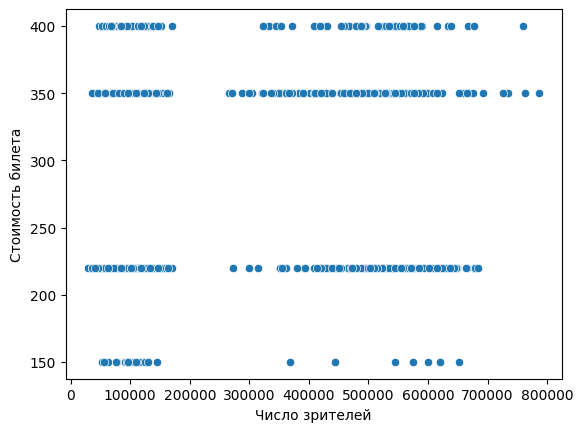

In [ ]:
sns.scatterplot(data=movies,
                x='Число зрителей',
                y='Стоимость билета')

2. **График распределения**

Ещё одним полезным графиком при анализе данных является график распределения значений. На нём показано, сколько раз встречается каждое значение в заданном наборе данных.

Чтобы построить график распределения с помощью seaborn, нужно воспользоваться функцией histoplot. Она принимает в качестве аргумента набор значений (в частности, колонку таблицы), распределение которых нужно построить, а также необязательный ключевой аргумент bins — количество диапазонов, на которые нужно разбить множество возможных значений при построении графика.

sns.histplot(movies['Год производства'],
             bins=len(movies['Год производства'].unique()))

<Axes: xlabel='Жанр фильма', ylabel='Count'>

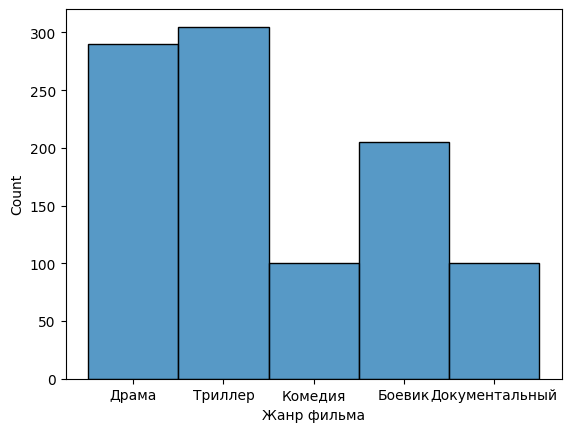

In [ ]:
sns.histplot(movies['Жанр фильма'],
             bins=len(movies['Жанр фильма'].unique()))

3. **Графики зависимости каждого фактора от каждого другого фактора**

В seaborn существует возможность построить графики зависимости каждой колонки какой-то таблицы от каждой другой колонки этой таблицы. Для этого нужно воспользоваться функцией pairplot, передав в неё исходную таблицу:

sns.pairplot(movies[['Год производства', 'Общая продолжительность']])

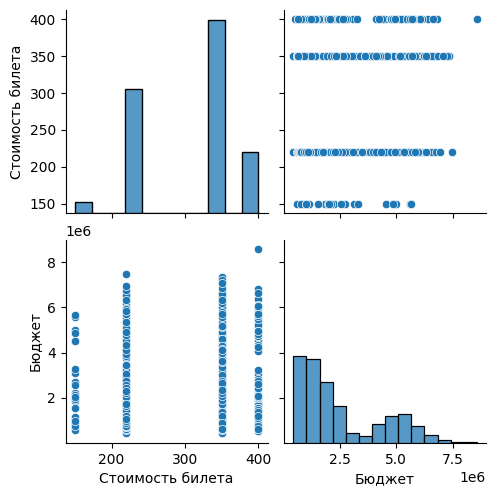

In [ ]:
sns.pairplot(movies[['Стоимость билета', 'Бюджет']])